In [7]:
import sys
!{sys.executable} -m pip install xgboost

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

In [9]:
import requests

def fetch_tunisia_weather():
    """
    Récupère les données météo historiques de la Tunisie
    via Open-Meteo (gratuit, pas de clé API requise)
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": 36.8,       # Tunis
        "longitude": 10.18,
        "start_date": "2020-01-01",
        "end_date": "2024-12-31",
        "daily": [
            "temperature_2m_max",
            "temperature_2m_min",
            "precipitation_sum",
            "windspeed_10m_max",
            "weathercode"
        ],
        "timezone": "Africa/Tunis"
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    df = pd.DataFrame(data["daily"])
    df.rename(columns={
        "time": "date",
        "temperature_2m_max": "temp_max",
        "temperature_2m_min": "temp_min",
        "precipitation_sum": "precipitation",
        "windspeed_10m_max": "windspeed",
        "weathercode": "weather_code"
    }, inplace=True)
    
    return df

df = fetch_tunisia_weather()
df.head()

,date,temp_max,temp_min,precipitation,windspeed,weather_code
0,2020-01-01,13.9,6.1,0.0,19.0,3
1,2020-01-02,16.2,7.1,0.0,14.8,2
2,2020-01-03,15.9,5.7,0.0,10.2,2
3,2020-01-04,15.9,7.7,0.1,19.7,51
4,2020-01-05,15.9,10.6,0.1,24.8,51


In [4]:
# Conversion de la date
df['date'] = pd.to_datetime(df['date'])
df['day']    = df['date'].dt.day
df['month']  = df['date'].dt.month
df['year']   = df['date'].dt.year
df['season'] = df['month'].map({
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring',  4: 'spring', 5: 'spring',
    6: 'summer',  7: 'summer', 8: 'summer',
    9: 'autumn', 10: 'autumn', 11: 'autumn'
})

# Créer la variable cible : type de météo
def classify_weather(row):
    if row['precipitation'] > 5:
        return 'rainy'
    elif row['temp_max'] > 35:
        return 'hot'
    elif row['temp_max'] < 15:
        return 'cold'
    elif row['windspeed'] > 40:
        return 'windy'
    else:
        return 'clear'

df['weather_type'] = df.apply(classify_weather, axis=1)

# Encoder les variables catégorielles
le_season  = LabelEncoder()
le_weather = LabelEncoder()
df['season_encoded']  = le_season.fit_transform(df['season'])
df['weather_encoded'] = le_weather.fit_transform(df['weather_type'])

# Features & Target
features = ['temp_max', 'temp_min', 'precipitation', 'windspeed',
            'day', 'month', 'season_encoded']
X = df[features]
y = df['weather_encoded']

# Gestion des valeurs manquantes
X = X.fillna(X.median())

print("Classes:", le_weather.classes_)
print("Distribution:\n", df['weather_type'].value_counts())

Classes: ['clear' 'cold' 'hot' 'rainy' 'windy']
Distribution:
 weather_type
clear    1375
hot       238
rainy     116
cold       92
windy       6
Name: count, dtype: int64


KeyError: 'month'

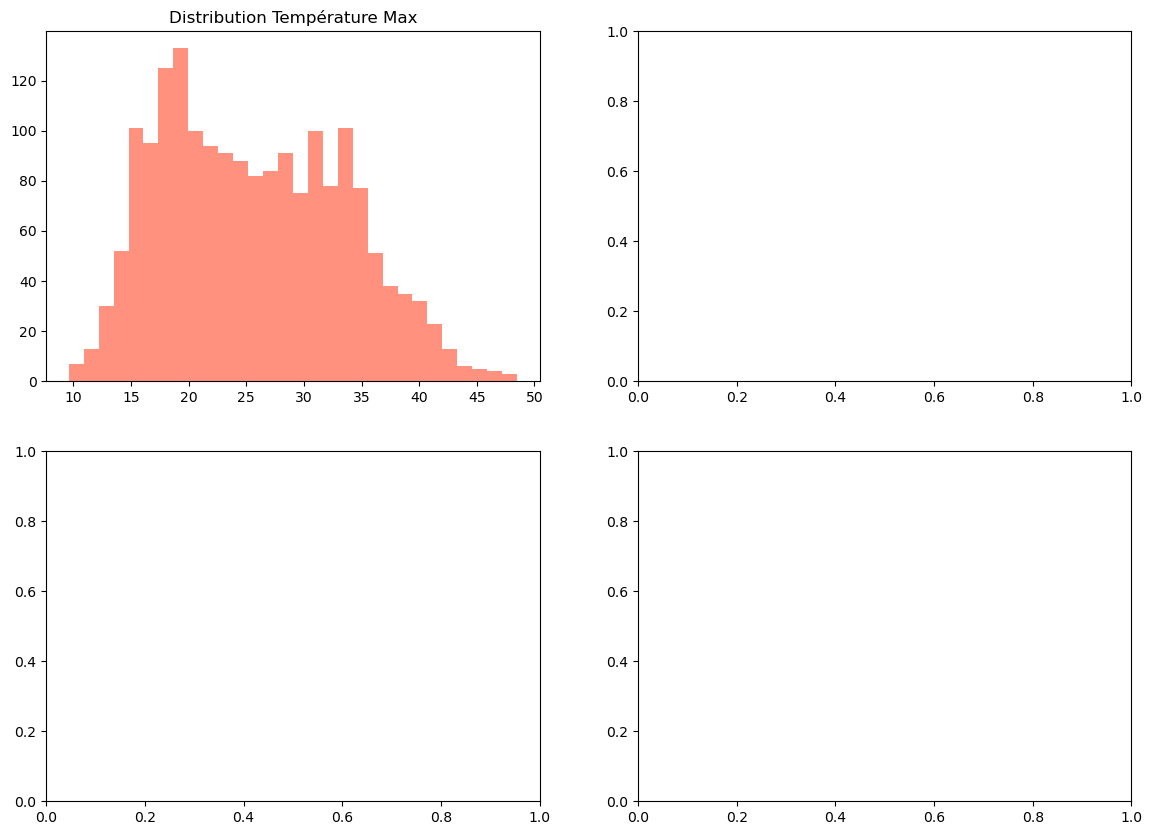

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution des températures
axes[0,0].hist(df['temp_max'], bins=30, color='tomato', alpha=0.7)
axes[0,0].set_title('Distribution Température Max')

# Précipitations par mois
df.groupby('month')['precipitation'].mean().plot(ax=axes[0,1], kind='bar', color='steelblue')
axes[0,1].set_title('Précipitations moyennes par mois')

# Distribution des types de météo
df['weather_type'].value_counts().plot(ax=axes[1,0], kind='pie', autopct='%1.1f%%')
axes[1,0].set_title('Répartition des types de météo')

# Température par saison
df.boxplot(column='temp_max', by='season', ax=axes[1,1])
axes[1,1].set_title('Température max par saison')

plt.tight_layout()
plt.savefig('weather_eda.png', dpi=150)
plt.show()

In [6]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Modèle XGBoost
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# Évaluation
y_pred = model.predict(X_test)
print(f"\n✅ Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n📊 Rapport:\n", classification_report(y_test, y_pred, target_names=le_weather.classes_))

[0]	validation_0-mlogloss:0.66503
[50]	validation_0-mlogloss:0.03298
[100]	validation_0-mlogloss:0.02472
[150]	validation_0-mlogloss:0.02623
[199]	validation_0-mlogloss:0.02781

✅ Accuracy: 0.9918

📊 Rapport:
               precision    recall  f1-score   support

       clear       1.00      0.99      0.99       276
        cold       0.90      1.00      0.95        18
         hot       1.00      1.00      1.00        48
       rainy       1.00      1.00      1.00        23
       windy       0.00      0.00      0.00         1

    accuracy                           0.99       366
   macro avg       0.78      0.80      0.79       366
weighted avg       0.99      0.99      0.99       366



In [11]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(model,      'models/xgboost_weather.pkl')
joblib.dump(le_season,  'models/label_encoder_season.pkl')
joblib.dump(le_weather, 'models/label_encoder_weather.pkl')

print("✅ Modèle sauvegardé dans models/")

✅ Modèle sauvegardé dans models/
